In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from xgboost import XGBRegressor
from collections import Counter
import pickle
import json
print("Imports done!")


Imports done!


In [2]:
df = pd.read_csv("train.csv", encoding="latin1")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (50065, 29)
Columns: ['id', 'log_price', 'property_type', 'room_type', 'amenities', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'description', 'first_review', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'host_since', 'instant_bookable', 'last_review', 'latitude', 'longitude', 'name', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'thumbnail_url', 'zipcode', 'bedrooms', 'beds']


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [3]:
df.isnull().sum()

id                            0
log_price                     0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                   146
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
description                   0
first_review              10730
host_has_profile_pic        127
host_identity_verified      127
host_response_rate        12358
host_since                  127
instant_bookable              0
last_review               10702
latitude                      0
longitude                     0
name                          0
neighbourhood              4622
number_of_reviews             0
review_scores_rating      11321
thumbnail_url              5601
zipcode                     642
bedrooms                     64
beds                         92
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50065 entries, 0 to 50064
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      50065 non-null  int64  
 1   log_price               50065 non-null  float64
 2   property_type           50065 non-null  str    
 3   room_type               50065 non-null  str    
 4   amenities               50065 non-null  str    
 5   accommodates            50065 non-null  int64  
 6   bathrooms               49919 non-null  float64
 7   bed_type                50065 non-null  str    
 8   cancellation_policy     50065 non-null  str    
 9   cleaning_fee            50065 non-null  bool   
 10  city                    50065 non-null  str    
 11  description             50065 non-null  str    
 12  first_review            39335 non-null  str    
 13  host_has_profile_pic    49938 non-null  str    
 14  host_identity_verified  49938 non-null  str    
 

In [5]:
df.describe()

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,5.006500e+04,50065.000000,50065.000000,49919.000000,50065.000000,50065.000000,50065.000000,38744.000000,50001.000000,49973.000000
mean,1.126250e+07,4.781653,3.157036,1.235041,38.440718,-92.442579,20.990013,94.054950,1.266615,1.712165
std,6.086537e+06,0.717339,2.164549,0.581885,3.082439,21.719474,38.115625,7.871467,0.853660,1.259446
min,3.440000e+02,0.000000,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,6.248335e+06,4.317488,2.000000,1.000000,34.125059,-118.343063,1.000000,92.000000,1.000000,1.000000
50%,1.225468e+07,4.709530,2.000000,1.000000,40.662201,-76.997580,6.000000,96.000000,1.000000,1.000000
75%,1.641344e+07,5.220356,4.000000,1.000000,40.745993,-73.954598,24.000000,100.000000,1.000000,2.000000
max,2.122836e+07,7.600402,16.000000,8.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,16.000000


In [ ]:

FRONTEND_AMENITIES = {
    "wifi":     "wireless internet",
    "ac":       "air conditioning",
    "kitchen":  "kitchen",
    "tv":       "tv",
    "washer":   "washer",
    "parking":  "free parking on premises",
    "elevator": "elevator",
    "pets":     "pets allowed",
}

def parse_amenities(val):
    if pd.isna(val): return []
    val = str(val).strip().strip("{}")
    items = [x.strip().strip(chr(34)).lower() for x in val.split(",")]
    return [i for i in items if i]

df["amenities_list"] = df["amenities"].apply(parse_amenities)

for frontend_key, dataset_name in FRONTEND_AMENITIES.items():
    col = "amen_" + frontend_key
    df[col] = df["amenities_list"].apply(lambda x: 1 if dataset_name in x else 0)


df.drop(columns=["amenities", "amenities_list"], inplace=True)

amen_cols = [c for c in df.columns if c.startswith("amen_")]
print("Amenity columns:", amen_cols)
print("\nAmenity presence in dataset (%):")
print((df[amen_cols].mean() * 100).round(1).to_string())


Amenity columns: ['amen_wifi', 'amen_ac', 'amen_kitchen', 'amen_tv', 'amen_washer', 'amen_parking', 'amen_elevator', 'amen_pets']

Amenity presence in dataset (%):
amen_wifi        96.1
amen_ac          74.5
amen_kitchen     91.2
amen_tv          70.4
amen_washer      58.0
amen_parking     31.9
amen_elevator    14.6
amen_pets        13.6


In [ ]:
le_encoders = {}


catcol = df.select_dtypes(include=["object", "bool"]).columns
catcol = [c for c in catcol if not c.startswith("amen_")]

for col in catcol:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_encoders[col] = le

print("Label encoded columns:", catcol)
df.head()


C:\Users\DELL\AppData\Local\Temp\ipykernel_22340\3777310918.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catcol = df.select_dtypes(include=["object", "bool"]).columns


Label encoded columns: ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'description', 'first_review', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'host_since', 'instant_bookable', 'last_review', 'name', 'neighbourhood', 'thumbnail_url', 'zipcode']


,id,log_price,property_type,room_type,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,bedrooms,beds,amen_wifi,amen_ac,amen_kitchen,amen_tv,amen_washer,amen_parking,amen_elevator,amen_pets
0,6901257,5.010635,0,0,3,1.0,4,2,1,4,...,1.0,1.0,1,1,1,0,0,0,0,0
1,6304928,5.129899,0,0,7,1.0,4,2,1,4,...,3.0,3.0,1,1,1,0,1,0,0,0
2,7919400,4.976734,0,0,5,1.0,4,1,1,4,...,1.0,3.0,1,1,1,1,0,0,0,0
3,13418779,6.620073,17,0,4,1.0,4,0,1,5,...,2.0,2.0,1,0,1,1,1,0,0,0
4,3808709,4.744932,0,0,2,1.0,4,1,1,2,...,0.0,1.0,1,1,1,1,0,0,0,0


In [8]:
df["beds_and_baths"] = df["bedrooms"] + df["bathrooms"]

corr = df.corr(numeric_only=True)
print("Correlation with log_price:")
print(corr["log_price"].sort_values(ascending=False))


Correlation with log_price:
log_price                 1.000000
accommodates              0.568585
bedrooms                  0.473689
beds_and_baths            0.473146
beds                      0.444552
bathrooms                 0.348572
amen_tv                   0.263143
amen_washer               0.165032
cancellation_policy       0.135764
cleaning_fee              0.108815
amen_kitchen              0.098000
amen_elevator             0.097396
bed_type                  0.091628
review_scores_rating      0.091358
amen_pets                 0.086362
first_review              0.056069
amen_parking              0.055042
amen_ac                   0.053669
property_type             0.051717
zipcode                   0.047959
last_review               0.047133
thumbnail_url             0.040928
neighbourhood             0.035677
amen_wifi                 0.030912
host_response_rate        0.029160
city                      0.028272
host_identity_verified    0.020512
id                       -0

In [9]:
df.drop(columns=[
    "zipcode", "latitude", "longitude", "thumbnail_url",
    "last_review", "id", "description", "first_review",
    "host_has_profile_pic", "host_identity_verified", "host_since", "name"
], inplace=True, errors="ignore")

print("Remaining columns:", df.columns.tolist())
print("Shape:", df.shape)


Remaining columns: ['log_price', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'host_response_rate', 'instant_bookable', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'bedrooms', 'beds', 'amen_wifi', 'amen_ac', 'amen_kitchen', 'amen_tv', 'amen_washer', 'amen_parking', 'amen_elevator', 'amen_pets', 'beds_and_baths']
Shape: (50065, 25)


In [10]:
df.dropna(subset=["beds_and_baths"], inplace=True)
df["review_scores_rating"] = df["review_scores_rating"].fillna(df["review_scores_rating"].mean())
df.isnull().sum()


log_price                0
property_type            0
room_type                0
accommodates             0
bathrooms                0
bed_type                 0
cancellation_policy      0
cleaning_fee             0
city                     0
host_response_rate       0
instant_bookable         0
neighbourhood            0
number_of_reviews        0
review_scores_rating     0
bedrooms                 0
beds                    36
amen_wifi                0
amen_ac                  0
amen_kitchen             0
amen_tv                  0
amen_washer              0
amen_parking             0
amen_elevator            0
amen_pets                0
beds_and_baths           0
dtype: int64

In [ ]:
pt = PowerTransformer(method='yeo-johnson')


cols_to_transform = [
    'accommodates', 'bathrooms', 'cleaning_fee',
    'host_response_rate', 'number_of_reviews',
    'review_scores_rating', 'bedrooms', 'beds',
    'beds_and_baths', 'price_per_room'
]


cols_to_transform = [c for c in cols_to_transform if c in df.columns]

for col in cols_to_transform:
    try:
        df[col] = pt.fit_transform(df[[col]])
    except Exception as e:
        print(f"Skipping {col}: {e}")

print("Transformed:", cols_to_transform)
print("NOT transformed (categorical + amenity):", 
      [c for c in df.columns if c not in cols_to_transform and c != 'log_price'])

Transformed: ['accommodates', 'bathrooms', 'cleaning_fee', 'host_response_rate', 'number_of_reviews', 'review_scores_rating', 'bedrooms', 'beds', 'beds_and_baths']
NOT transformed (categorical + amenity): ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city', 'instant_bookable', 'neighbourhood', 'amen_wifi', 'amen_ac', 'amen_kitchen', 'amen_tv', 'amen_washer', 'amen_parking', 'amen_elevator', 'amen_pets']


In [12]:
df["price_per_room"] = df["log_price"] / df["beds_and_baths"].replace(0, 1)


In [13]:
Features = df.drop(columns=["log_price"])
Labels = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    Features, Labels, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Features used:", Features.columns.tolist())
print("Total features:", len(Features.columns))


Train size: (39888, 25)
Test size: (9972, 25)
Features used: ['property_type', 'room_type', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'host_response_rate', 'instant_bookable', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'bedrooms', 'beds', 'amen_wifi', 'amen_ac', 'amen_kitchen', 'amen_tv', 'amen_washer', 'amen_parking', 'amen_elevator', 'amen_pets', 'beds_and_baths', 'price_per_room']
Total features: 25


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("R2 Score (Random Forest):", round(rf.score(X_test, y_test), 4))


R2 Score (Random Forest): 0.9954


In [15]:
xg = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
xg.fit(X_train, y_train)
pred = xg.predict(X_test)
print("R2 Score (XGBoost):", round(xg.score(X_test, y_test), 4))


R2 Score (XGBoost): 0.9968


In [16]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 7],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3],
    "reg_alpha": [0, 0.1, 0.5, 1],
    "reg_lambda": [1, 1.5, 2]
}

xgb = XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1)

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20, cv=3, verbose=2,
    random_state=42, n_jobs=-1, scoring="r2"
)

xgb_random.fit(X_train, y_train)

print("Best Parameters:", xgb_random.best_params_)
print("Best CV R2 Score:", round(xgb_random.best_score_, 4))

best_xgb = xgb_random.best_estimator_
best_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    early_stopping_rounds=30,
    verbose=True
)

pred = best_xgb.predict(X_test)
print("Test R2 Score:", round(best_xgb.score(X_test, y_test), 4))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}
Best CV R2 Score: 0.9959
[0]	validation_0-rmse:3.91999
[1]	validation_0-rmse:3.53025
[2]	validation_0-rmse:3.17989


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\xgboost\sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[3]	validation_0-rmse:2.86389
[4]	validation_0-rmse:2.57986
[5]	validation_0-rmse:2.32403
[6]	validation_0-rmse:2.09395
[7]	validation_0-rmse:1.88675
[8]	validation_0-rmse:1.70008
[9]	validation_0-rmse:1.53234
[10]	validation_0-rmse:1.38138
[11]	validation_0-rmse:1.24525
[12]	validation_0-rmse:1.12299
[13]	validation_0-rmse:1.01313
[14]	validation_0-rmse:0.91393
[15]	validation_0-rmse:0.82497
[16]	validation_0-rmse:0.74492
[17]	validation_0-rmse:0.67322
[18]	validation_0-rmse:0.60839
[19]	validation_0-rmse:0.55058
[20]	validation_0-rmse:0.49868
[21]	validation_0-rmse:0.45210
[22]	validation_0-rmse:0.40999
[23]	validation_0-rmse:0.37213
[24]	validation_0-rmse:0.33831
[25]	validation_0-rmse:0.30785
[26]	validation_0-rmse:0.28068
[27]	validation_0-rmse:0.25631
[28]	validation_0-rmse:0.23523
[29]	validation_0-rmse:0.21597
[30]	validation_0-rmse:0.19899
[31]	validation_0-rmse:0.18425
[32]	validation_0-rmse:0.16967
[33]	validation_0-rmse:0.15781
[34]	validation_0-rmse:0.14596
[35]	validation

In [17]:
cv_scores = cross_val_score(
    xg, Features, Labels,
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    scoring="r2"
)
print("Cross-val R2 scores:", cv_scores.round(4))
print("Mean R2:", round(cv_scores.mean(), 4))
print("Std:", round(cv_scores.std(), 4))


Cross-val R2 scores: [0.9964 0.9968 0.9969 0.9966 0.9961 0.9947 0.9981 0.9958 0.9958 0.9971]
Mean R2: 0.9964
Std: 0.0009


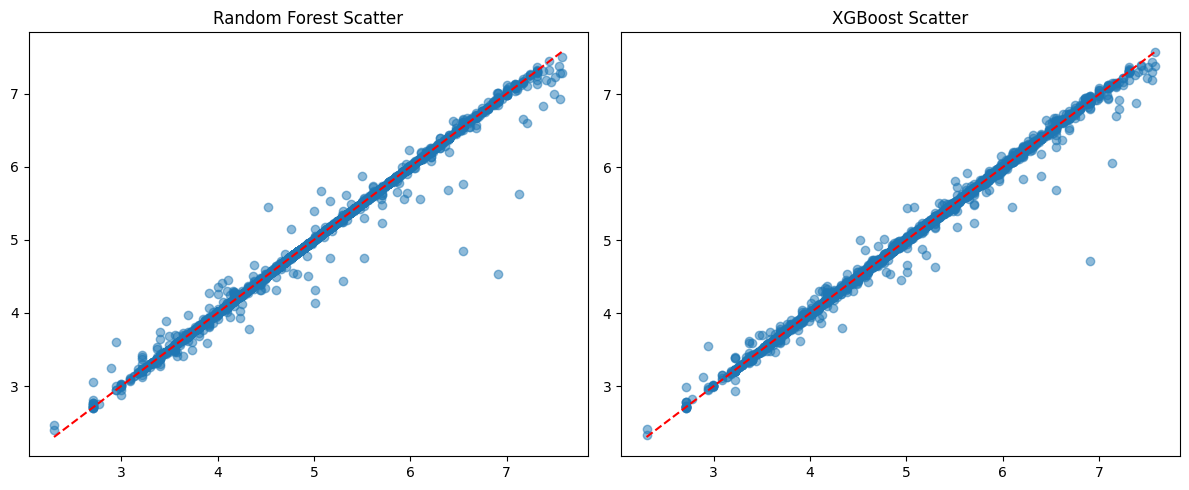

In [18]:
rf_df = pd.DataFrame({"Actual": y_test, "Predicted": pred_rf})
xgb_df = pd.DataFrame({"Actual": y_test, "Predicted": pred})

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Random Forest Scatter")
plt.subplot(1,2,2)
plt.scatter(y_test, pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("XGBoost Scatter")
plt.tight_layout()
plt.show()


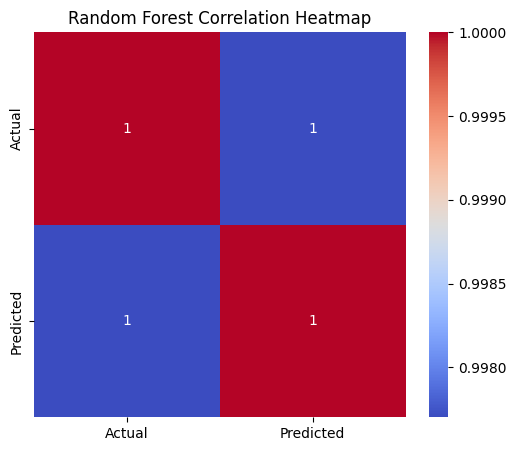

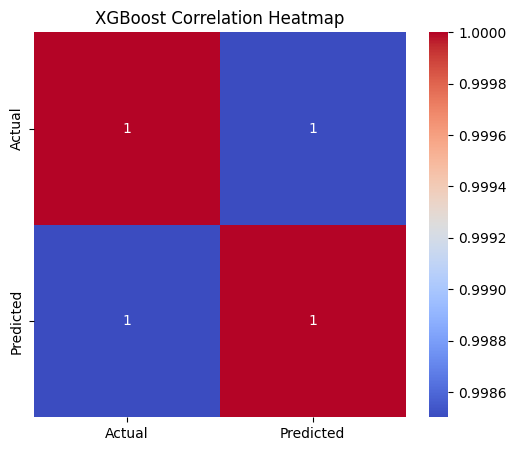

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Random Forest
rf_df = pd.DataFrame({'Actual': y_test, 'Predicted': pred_rf})
plt.figure(figsize=(6,5))
sns.heatmap(rf_df.corr(), annot=True, cmap='coolwarm')
plt.title('Random Forest Correlation Heatmap')
plt.show()

# XGBoost
xgb_df = pd.DataFrame({'Actual': y_test, 'Predicted': pred})
plt.figure(figsize=(6,5))
sns.heatmap(xgb_df.corr(), annot=True, cmap='coolwarm')
plt.title('XGBoost Correlation Heatmap')
plt.show()

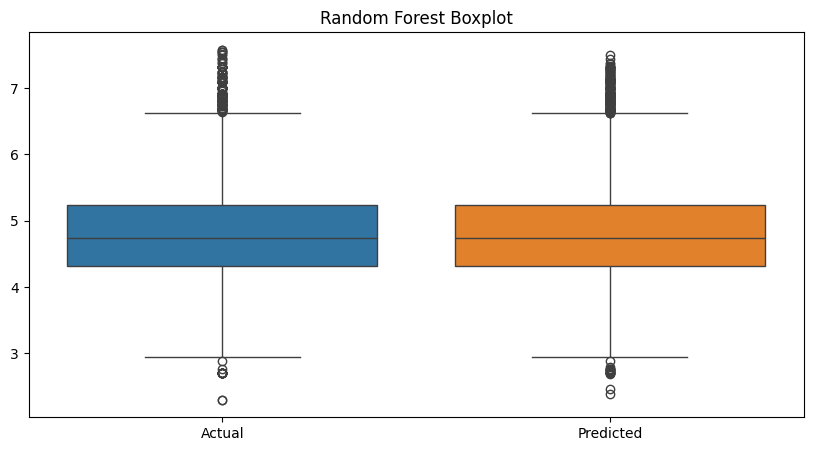

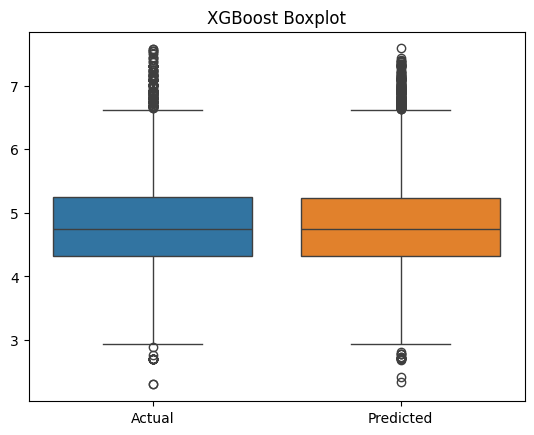

In [20]:
import seaborn as sns
plt.figure(figsize=(10,5))

# Random Forest
sns.boxplot(data=rf_df)
plt.title('Random Forest Boxplot')
plt.show()

# XGBoost
sns.boxplot(data=xgb_df)
plt.title('XGBoost Boxplot')
plt.show()

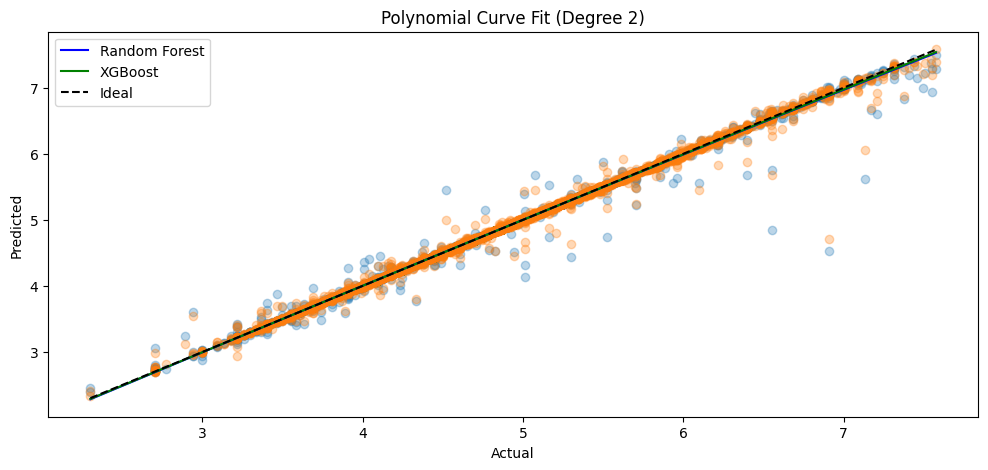

In [21]:
import numpy as np
plt.figure(figsize=(12,5))

# Random Forest
coeffs_rf = np.polyfit(y_test, pred_rf, deg=2)
poly_rf = np.poly1d(coeffs_rf)
plt.scatter(y_test, pred_rf, alpha=0.3)
plt.plot(np.sort(y_test), poly_rf(np.sort(y_test)), label='Random Forest', color='blue')

# XGBoost
coeffs_xgb = np.polyfit(y_test, pred, deg=2)
poly_xgb = np.poly1d(coeffs_xgb)
plt.scatter(y_test, pred, alpha=0.3)
plt.plot(np.sort(y_test), poly_xgb(np.sort(y_test)), label='XGBoost', color='green')

# Ideal line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='Ideal')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Polynomial Curve Fit (Degree 2)')
plt.legend()
plt.show()

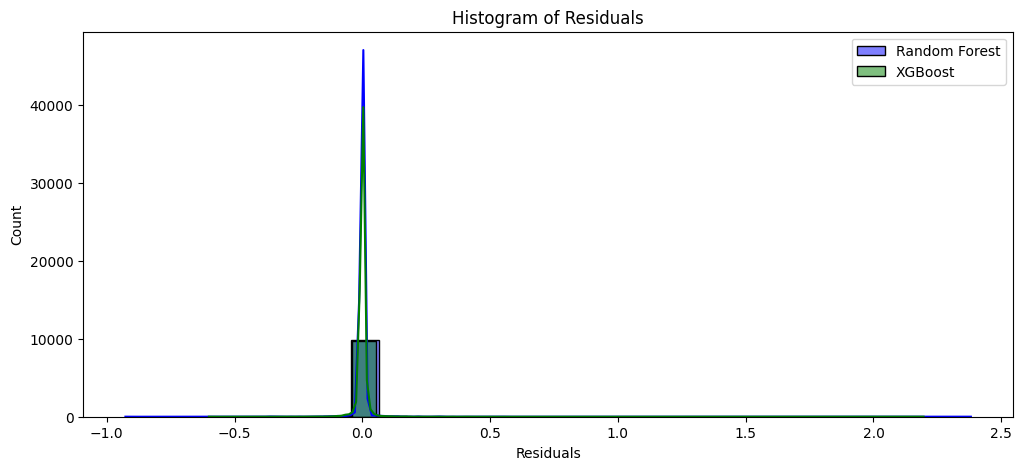

In [22]:
plt.figure(figsize=(12,5))

# Random Forest residuals
residuals_rf = y_test - pred_rf
sns.histplot(residuals_rf, kde=True, color='blue', alpha=0.5, bins=30, label='Random Forest')

# XGBoost residuals
residuals_xgb = y_test - pred
sns.histplot(residuals_xgb, kde=True, color='green', alpha=0.5, bins=30, label='XGBoost')

plt.xlabel('Residuals')
plt.title('Histogram of Residuals')
plt.legend()
plt.show()

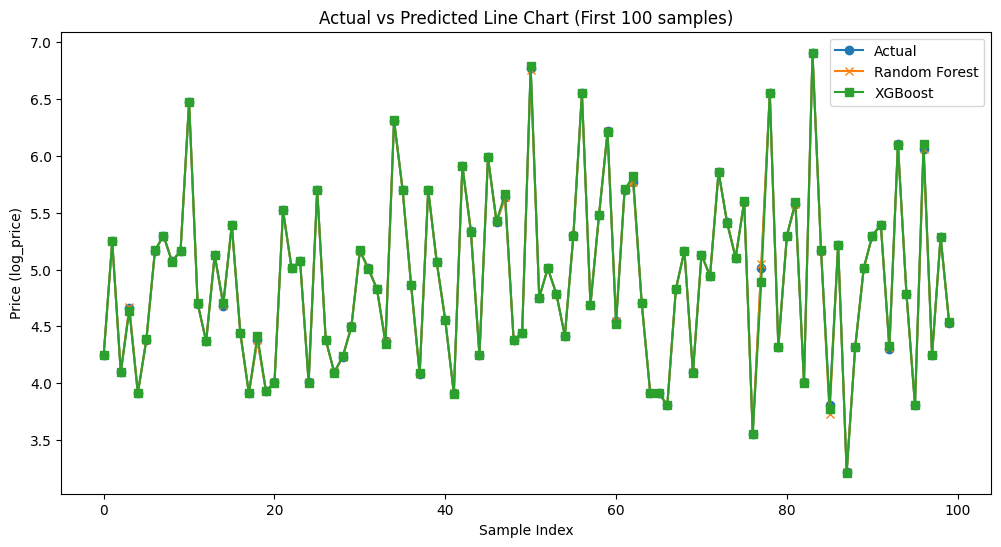

In [23]:
plt.figure(figsize=(12,6))

plt.plot(y_test[:100].values, label='Actual', marker='o')
plt.plot(pred_rf[:100], label='Random Forest', marker='x')
plt.plot(pred[:100], label='XGBoost', marker='s')

plt.xlabel('Sample Index')
plt.ylabel('Price (log_price)')
plt.title('Actual vs Predicted Line Chart (First 100 samples)')
plt.legend()
plt.show()

In [24]:
import pickle
import os
import json
import pathlib
 

desktop = pathlib.Path.home() / "Desktop"
MODEL_DIR = desktop / "prediction" / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
 
print(f"Model folder ready at:\n   {MODEL_DIR}")

Model folder ready at:
   C:\Users\DELL\Desktop\prediction\model


In [25]:
model_path = MODEL_DIR / "xgb_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_xgb, f)
print(f"XGBoost model saved: {model_path}")

encoders_path = MODEL_DIR / "label_encoders.pkl"
with open(encoders_path, "wb") as f:
    pickle.dump(le_encoders, f)
print(f"Label encoders saved: {encoders_path}")

from sklearn.preprocessing import PowerTransformer
import numpy as np

feature_cols = Features.columns.tolist()

# ✅ Sirf numeric columns ka pt_dict — categorical aur amenity skip
numeric_cols = [
    'accommodates', 'bathrooms', 'cleaning_fee',
    'host_response_rate', 'number_of_reviews',
    'review_scores_rating', 'bedrooms', 'beds',
    'beds_and_baths', 'price_per_room'
]

pt_dict = {}
X_train_copy = X_train.copy()

for col in numeric_cols:
    if col not in X_train_copy.columns:
        print(f"Skipping {col}: not in training data")
        continue
    pt_col = PowerTransformer(method='yeo-johnson')
    try:
        pt_col.fit(X_train_copy[[col]])
        pt_dict[col] = pt_col
        print(f"PT saved for: {col}")
    except Exception as e:
        print(f"Skipping PT for {col}: {e}")

print("\nFinal PT dict keys:", list(pt_dict.keys()))

pt_dict_path = MODEL_DIR / "power_transformers.pkl"
with open(pt_dict_path, "wb") as f:
    pickle.dump(pt_dict, f)
print(f"Power transformers saved: {pt_dict_path}")

feature_names_path = MODEL_DIR / "feature_names.pkl"
with open(feature_names_path, "wb") as f:
    pickle.dump(feature_cols, f)
print(f"Feature names saved: {feature_names_path}")

rating_mean = float(df['review_scores_rating'].mean() if 'review_scores_rating' in df.columns else 85.0)
meta = {
    "rating_mean": rating_mean,
    "model_version": "2.0",
    "features": feature_cols
}
meta_path = MODEL_DIR / "meta.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f"Meta info saved: {meta_path}")




XGBoost model saved: C:\Users\DELL\Desktop\prediction\model\xgb_model.pkl
Label encoders saved: C:\Users\DELL\Desktop\prediction\model\label_encoders.pkl
PT saved for: accommodates
PT saved for: bathrooms
PT saved for: cleaning_fee
PT saved for: host_response_rate
PT saved for: number_of_reviews
PT saved for: review_scores_rating
PT saved for: bedrooms
PT saved for: beds
PT saved for: beds_and_baths
PT saved for: price_per_room

Final PT dict keys: ['accommodates', 'bathrooms', 'cleaning_fee', 'host_response_rate', 'number_of_reviews', 'review_scores_rating', 'bedrooms', 'beds', 'beds_and_baths', 'price_per_room']
Power transformers saved: C:\Users\DELL\Desktop\prediction\model\power_transformers.pkl
Feature names saved: C:\Users\DELL\Desktop\prediction\model\feature_names.pkl
Meta info saved: C:\Users\DELL\Desktop\prediction\model\meta.json


In [26]:
print("\n" + "="*50)
print("VERIFICATION: Loading saved model & testing...")
print("="*50)
 
with open(MODEL_DIR / "xgb_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
 

test_input = X_test.iloc[[0]]
pred_loaded = loaded_model.predict(test_input)[0]
pred_original = best_xgb.predict(test_input)[0]
 
print(f"Original model prediction : {np.expm1(pred_original):.2f}")
print(f"Loaded model prediction   : {np.expm1(pred_loaded):.2f}")
 
if abs(pred_loaded - pred_original) < 0.001:
    print("Model loaded & verified successfully!")
else:
    print("Small numerical difference (normal), model is fine.")
 
print(f"\nALL FILES SAVED IN:\n   {MODEL_DIR}")
print("\nFiles:")
for f in sorted(MODEL_DIR.iterdir()):
    print(f"{f.name}  ({f.stat().st_size / 1024:.1f} KB)")
 



VERIFICATION: Loading saved model & testing...
Original model prediction : 69.14
Loaded model prediction   : 69.14
Model loaded & verified successfully!

ALL FILES SAVED IN:
   C:\Users\DELL\Desktop\prediction\model

Files:
amenity_meta.json  (0.3 KB)
feature_names.pkl  (0.4 KB)
label_encoders.pkl  (43755.4 KB)
meta.json  (0.6 KB)
power_transformers.pkl  (3.5 KB)
xgb_model.pkl  (1514.6 KB)


In [27]:
import pickle
feat = pickle.load(open('model/feature_names.pkl', 'rb'))
print(feat)
print(len(feat))

['property_type', 'room_type', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'host_response_rate', 'instant_bookable', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'bedrooms', 'beds', 'amen_wifi', 'amen_ac', 'amen_kitchen', 'amen_tv', 'amen_washer', 'amen_parking', 'amen_elevator', 'amen_pets', 'beds_and_baths', 'price_per_room']
25


In [28]:
import pickle, numpy as np, pandas as pd, math

model   = pickle.load(open('model/xgb_model.pkl', 'rb'))
pt_dict = pickle.load(open('model/power_transformers.pkl', 'rb'))
feat    = pickle.load(open('model/feature_names.pkl', 'rb'))
le      = pickle.load(open('model/label_encoders.pkl', 'rb'))

print("Features:", feat)
print("\nRoom type classes:", le['room_type'].classes_)
print("City classes:", le['city'].classes_)

Features: ['property_type', 'room_type', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'host_response_rate', 'instant_bookable', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'bedrooms', 'beds', 'amen_wifi', 'amen_ac', 'amen_kitchen', 'amen_tv', 'amen_washer', 'amen_parking', 'amen_elevator', 'amen_pets', 'beds_and_baths', 'price_per_room']

Room type classes: ['Entire home/apt' 'Private room' 'Shared room']
City classes: ['Boston' 'Chicago' 'DC' 'LA' 'NYC' 'SF']


In [29]:
import pickle, numpy as np, pandas as pd, math

model   = pickle.load(open('model/xgb_model.pkl', 'rb'))
pt_dict = pickle.load(open('model/power_transformers.pkl', 'rb'))
feat    = pickle.load(open('model/feature_names.pkl', 'rb'))
le      = pickle.load(open('model/label_encoders.pkl', 'rb'))

print("PT dict keys:", list(pt_dict.keys()))
print("\nProperty type classes:", le['property_type'].classes_)
print("Cancellation classes:", le['cancellation_policy'].classes_)

PT dict keys: ['accommodates', 'bathrooms', 'cleaning_fee', 'host_response_rate', 'number_of_reviews', 'review_scores_rating', 'bedrooms', 'beds', 'beds_and_baths', 'price_per_room']

Property type classes: ['Apartment' 'Bed & Breakfast' 'Boat' 'Boutique hotel' 'Bungalow' 'Cabin'
 'Camper/RV' 'Casa particular' 'Castle' 'Cave' 'Chalet' 'Condominium'
 'Dorm' 'Earth House' 'Guest suite' 'Guesthouse' 'Hostel' 'House' 'Hut'
 'In-law' 'Lighthouse' 'Loft' 'Other' 'Parking Space' 'Serviced apartment'
 'Tent' 'Timeshare' 'Tipi' 'Townhouse' 'Train' 'Treehouse' 'Vacation home'
 'Villa' 'Yurt']
Cancellation classes: ['flexible' 'moderate' 'strict' 'super_strict_30' 'super_strict_60']
